In [3]:
import pandas as pd

In [5]:
df = pd.read_csv("cleaned_bearing_data.csv")
df = df.dropna(subset=['bearing_make', 'industry_type', 'subscription_start', 'timestamp_of_fault'])

# Operational life in days
df['subscription_start'] = pd.to_datetime(df['subscription_start'])
df['timestamp_of_fault'] = pd.to_datetime(df['timestamp_of_fault'])
df['operational_days'] = (df['timestamp_of_fault'] - df['subscription_start']).dt.days


In [6]:
from itertools import combinations
from scipy.stats import ttest_ind, mannwhitneyu

results = []

for industry in df['industry_type'].unique():
    data_i = df[df['industry_type'] == industry]
    makes = data_i['bearing_make'].value_counts()
    eligible_makes = makes[makes >= 10].index

    if len(eligible_makes) < 2:
        continue

    for make_a, make_b in combinations(eligible_makes, 2):
        a_life = data_i[data_i['bearing_make'] == make_a]['operational_days'].dropna()
        b_life = data_i[data_i['bearing_make'] == make_b]['operational_days'].dropna()

        if len(a_life) < 10 or len(b_life) < 10:
            continue

        # Welch's t-test (or Mann-Whitney if needed)
        stat, p_value = ttest_ind(a_life, b_life, equal_var=False)
        lift = (a_life.mean() - b_life.mean()) / b_life.mean()

        results.append({
            "industry": industry,
            "make_a": make_a,
            "make_b": make_b,
            "mean_a": a_life.mean(),
            "mean_b": b_life.mean(),
            "lift_%": lift * 100,
            "p_value": p_value,
            "is_significant": p_value < 0.05 and lift >= 0.15
        })


In [8]:
import pandas as pd

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by=["industry", "p_value"])
comparison_df.to_csv("output/q1/make_comparison.csv", index=False)

# Filter only statistically + practically significant comparisons
significant = comparison_df[comparison_df['is_significant'] == True]


In [5]:
print("Total comparisons:", len(comparison_df))
print("Significant comparisons:", len(significant))

Total comparisons: 87
Significant comparisons: 28


In [6]:
print(significant)

       industry   make_a   make_b      mean_a      mean_b      lift_%  \
0    INDUSTRY_1   MAKE_1   MAKE_4  520.507415  394.745665   31.858931   
11   INDUSTRY_1   MAKE_5   MAKE_3  674.000000  345.921053   94.842145   
2    INDUSTRY_1   MAKE_1   MAKE_3  520.507415  345.921053   50.470002   
12   INDUSTRY_1   MAKE_5   MAKE_7  674.000000  424.900000   58.625559   
14   INDUSTRY_1   MAKE_5   MAKE_9  674.000000  495.666667   35.978480   
83  INDUSTRY_11   MAKE_3   MAKE_4  658.153846  169.833333  287.529252   
81  INDUSTRY_11   MAKE_1   MAKE_4  436.862069  169.833333  157.229874   
84  INDUSTRY_11   MAKE_7   MAKE_4  596.166667  169.833333  251.030422   
24   INDUSTRY_3   MAKE_1   MAKE_4  674.475904  484.150000   39.311351   
27   INDUSTRY_4   MAKE_1   MAKE_4  290.431373  138.111111  110.288202   
28   INDUSTRY_5   MAKE_1   MAKE_4  461.470899  370.989362   24.389254   
47   INDUSTRY_7   MAKE_5   MAKE_6  494.337209  284.431818   73.798140   
46   INDUSTRY_7   MAKE_5   MAKE_7  494.337209  368.

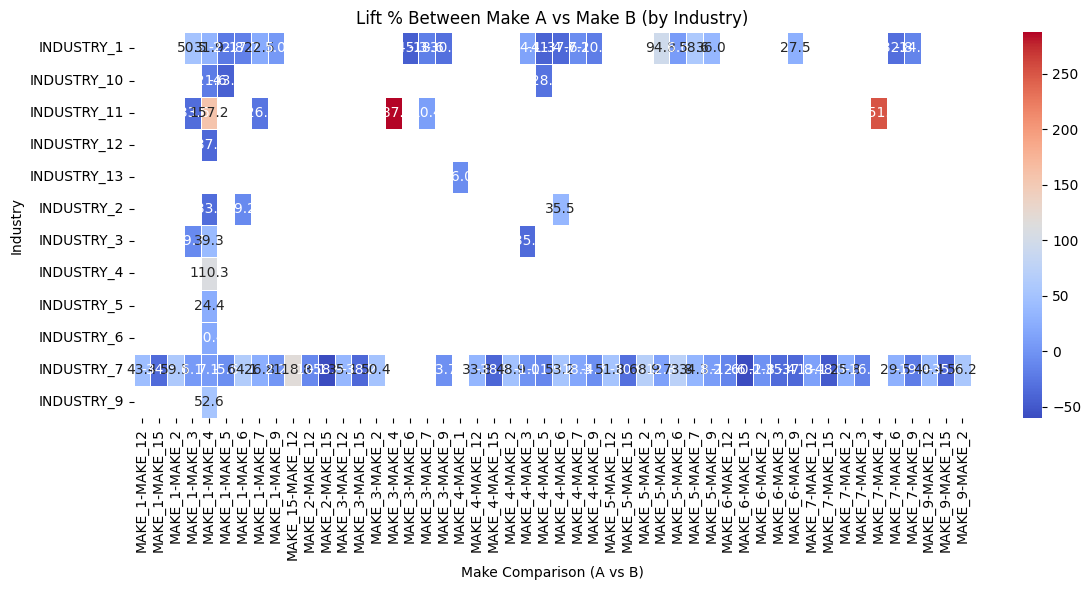

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Pivot to create a heatmap matrix (industry × make pairs)
heatmap_df = comparison_df.pivot_table(
    index="industry",
    columns=["make_a", "make_b"],
    values="lift_%",
    aggfunc="first"
)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_df, annot=True, cmap="coolwarm", fmt=".1f", linewidths=0.5)
plt.title("Lift % Between Make A vs Make B (by Industry)")
plt.xlabel("Make Comparison (A vs B)")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()


In [9]:
import plotly.express as px

# Filter for one industry at a time
industry = "INDUSTRY_12"
industry_data = comparison_df[comparison_df['industry'] == industry]

# Melt to reshape for bar plot
melted = pd.melt(industry_data, id_vars=['make_a', 'make_b'], value_vars=['mean_a', 'mean_b'], 
                 var_name='mean_type', value_name='mean_life')

melted['make'] = melted.apply(lambda row: row['make_a'] if row['mean_type'] == 'mean_a' else row['make_b'], axis=1)

px.bar(melted, x="make", y="mean_life", color="mean_type", barmode="group", 
       title=f"Mean Operational Life of Makes in {industry}")


In [10]:
import plotly.graph_objects as go

sig = comparison_df[comparison_df['is_significant']]
labels = list(set(sig['make_a']).union(set(sig['make_b'])))

source = [labels.index(row['make_b']) for _, row in sig.iterrows()]
target = [labels.index(row['make_a']) for _, row in sig.iterrows()]
value  = list(sig['lift_%'])

fig = go.Figure(go.Sankey(
    node=dict(label=labels, pad=15, thickness=20),
    link=dict(source=source, target=target, value=value)
))

fig.update_layout(title="Make Superiority Flow (Only Significant Lifts)", font_size=10)
fig.show()


In [11]:
fig = px.scatter(
    comparison_df,
    x='lift_%',
    y='p_value',
    color='is_significant',
    hover_data=['industry', 'make_a', 'make_b'],
    title="Comparison: Lift % vs p-value"
)
fig.update_yaxes(type='log')  # To show very small p-values clearly
fig.show()


In [12]:
ranked = comparison_df.copy()
ranked['lift_tag'] = ranked.apply(
    lambda row: f"{row['make_a']} > {row['make_b']}" if row['lift_%'] > 0 else f"{row['make_b']} > {row['make_a']}", axis=1
)

for industry in ranked['industry'].unique():
    subset = ranked[ranked['industry'] == industry]
    fig = px.bar(subset, x='lift_tag', y='lift_%', color='is_significant',
                 title=f"Make Lift Comparison in {industry}", labels={'lift_%': 'Lift %'})
    fig.show()


In [15]:
import pandas as pd

# Load and prepare data
df = pd.read_csv("cleaned_bearing_data.csv")
df['subscription_start'] = pd.to_datetime(df['subscription_start'])
df['timestamp_of_fault'] = pd.to_datetime(df['timestamp_of_fault'])
df['operational_days'] = (df['timestamp_of_fault'] - df['subscription_start']).dt.days
df['severity'] = df['bearing_severity_class'].fillna(0).astype(int)

# Minimum number of samples for a make to be considered
MIN_RECORDS = 10

best_makes = []

# Loop through each industry
for industry in df['industry_type'].dropna().unique():
    subset = df[df['industry_type'] == industry]

    # Group by make
    make_stats = subset.groupby('bearing_make').agg(
        count=('operational_days', 'count'),
        avg_life=('operational_days', 'mean'),
        failure_rate=('severity', lambda x: (x > 0).mean())
    ).reset_index()

    # Filter out makes with too few records
    make_stats = make_stats[make_stats['count'] >= MIN_RECORDS]

    if make_stats.empty:
        continue

    # Rank by avg_life, break ties by failure_rate
    make_stats = make_stats.sort_values(by=['avg_life', 'failure_rate'], ascending=[False, True])

    # Get best make for this industry
    best_row = make_stats.iloc[0]
    best_makes.append({
        'industry': industry,
        'best_make': best_row['bearing_make'],
        'avg_life': best_row['avg_life'],
        'failure_rate': best_row['failure_rate'],
        'record_count': best_row['count']
    })

# Create final summary table
best_make_df = pd.DataFrame(best_makes)
best_make_df = best_make_df.sort_values(by="avg_life", ascending=False)

# Save for dashboard
best_make_df.to_csv("q1/best_make_per_industry.csv", index=False)


In [16]:
import plotly.express as px

fig = px.bar(
    best_make_df,
    x='industry',
    y='avg_life',
    color='best_make',
    hover_data=['failure_rate', 'record_count'],
    title="🏆 Best Performing Make per Industry (Avg Life ≥ 10 samples)",
    labels={'avg_life': 'Avg Operational Life (days)'}
)
fig.update_layout(xaxis_title="Industry", yaxis_title="Avg Life")
fig.show()
